## FluSight Analysis: Current Season Performance

This notebook evaluates performance of models currently submitting to the CDC's FluSight Forecast Hub for target weekly incident influenza hospital admissions. For this analysis, we examine only the current season from 22 November 2025 to 1 April 2026. The inputs are quantile forecasts, and we examine 52 jurisdictions (50 states + Washington, DC + Puerto Rico). National-level (US) forecasts are excluded. Forecasts are submitted for horizons $[-1, 3]$, but this analysis excludes horizon $-1$.

The two main evaluation metrics are Weighted Interval Score (WIS) and log WIS (the same WIS scoring function applied to log transformed data), calculated in the same way as currently done for the CDC's own evaluations.

Main model comparisons consider only those models submitting for at least 80% of eligible forecasting tasks **and** with a season-average WIS ≤ 150, where the task space is defined over the required combination of location, reference date and prediction horizon, i.e., `one forecast task = one model x one reference date x one horizon x one location`. For each task, the submitted quantile forecast is compared against the current observed hospital admissions for the corresponding `target_end_date`.

#### imports & setup

In [23]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [24]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

from matplotlib.colors import LinearSegmentedColormap

from hub_config import FLU_HUB as HUB
from src.scoring import pairwise_relative_wis
import src.plotting as P
import src.colouring as C
from src.export import show_table

plt.rcParams.update({
    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "font.size": 15,          # base size
    "axes.titlesize": 20,     # subplot title
    "axes.labelsize": 20,     # x/y axis labels
    "xtick.labelsize": 18,    # x tick labels
    "ytick.labelsize": 18,    # y tick labels
    "legend.fontsize": 20,    # legend text
    "legend.title_fontsize": 20,
    "figure.titlesize": 20,   # suptitle
})

FOR_DISEASE = "flu"
PLTS_TO = f'figures/hubs/{FOR_DISEASE}'
os.makedirs(PLTS_TO, exist_ok=True)

In [25]:
EXPORT_TABLES = True
TABLE_PREFIX  = "flu"

In [26]:
# Location scope
# Toggle to include / exclude jurisdiction from ALL analyses
EXCLUDE_NATIONAL    = True   # US national-level aggregate
EXCLUDE_PUERTO_RICO = False  # Puerto Rico (FIPS 72)

EXCLUDE_LOCS = (
    (["US"] if EXCLUDE_NATIONAL    else []) +
    (["72"] if EXCLUDE_PUERTO_RICO else [])
)
print(f"Excluding locations: {EXCLUDE_LOCS or 'none'}")

Excluding locations: ['US']


In [27]:
scores_all = pd.read_parquet(HUB.scores_path)
scores = scores_all[
    (scores_all["horizon"] != -1) &
    (~scores_all["location"].isin(EXCLUDE_LOCS))
].copy()

# Task space
ALL_DATES    = sorted(scores["reference_date"].unique())
ALL_HORIZONS = sorted(scores["horizon"].unique())    # [0, 1, 2, 3]
ALL_LOCS     = sorted(scores["location"].unique())

N_DATES, N_HORIZONS, N_LOCS = len(ALL_DATES), len(ALL_HORIZONS), len(ALL_LOCS)

_scoreable = scores.groupby(["reference_date", "horizon", "location"]).size()
MAX_TASKS   = len(_scoreable)
SCOREABLE_DH = scores.groupby(["reference_date", "horizon"]).ngroups

ELIGIBILITY_THRESHOLD = 0.80
MAX_WIS_THRESHOLD     = 10000
ENSEMBLE   = HUB.ensemble_id
BASELINE   = HUB.baseline_id
GOOGLE     = HUB.google_id
HUB_MODELS = set(HUB.hub_model_ids)   # ensemble + baseline + extra ensembles


In [28]:
# Colour scheme
# Google = pink, hub models (ensemble, baseline, extra ensembles) = black, all others = grey
GREEN = C.GREEN
GOOGLE_PINK = C.GOOGLE_PINK
ALL_MODELS  = sorted(scores["model_id"].unique())
HUB_BLACK = C.HUB_BLACK
OTHER_GREY = C.OTHER_GREY
MODEL_COLOUR = {
    m: (
        GOOGLE_PINK if m == GOOGLE
        else HUB_BLACK if m in HUB_MODELS
        else OTHER_GREY
    )
    for m in scores["model_id"].unique()
}
MODEL_HATCH = {
    m: (
        "//" if m in HUB_MODELS
        else ""
    )
    for m in scores["model_id"].unique()
}


### Location submission check (here for Puerto Rico)

Uses `scores_all` (before location filtering) -- how many models submit for this location?

In [29]:
# CHECK_LOCATION = "72"  # Puerto Rico FIPS code
# _loc  = scores_all[(scores_all["horizon"] != -1) & (scores_all["location"] == CHECK_LOCATION)]
# _all = scores_all[ scores_all["horizon"] != -1]

# if _loc.empty:
#     print(f"{CHECK_LOCATION} has no scored tasks in this hub/season.")
# else:
#     _loc_count  = _loc.groupby("model_id").size().rename("Location tasks")
#     _tot_count = _all.groupby("model_id").size().rename("Total tasks")
#     _df = pd.concat([_loc_count, _tot_count], axis=1).fillna(0).astype(int)
#     _df["% of own tasks"] = _df["Location tasks"] / _df["Total tasks"]
#     _df = _df.sort_values("Location tasks", ascending=False)

#     print(f"Location ({CHECK_LOCATION}) scored tasks : {len(_loc):,}  over {_loc['reference_date'].nunique()} reference dates")
#     print(f"Models with location ({CHECK_LOCATION}) present : {(_df['Location tasks'] > 0).sum()} / {len(_df)}")
#     show_table(
#         _df.style
#         .format({f"% of own tasks": "{:.1%}"})
#         .background_gradient(subset=["Location tasks"], cmap="YlOrRd"),
#         "location_tasks", prefix=TABLE_PREFIX, export=False,
#     )

## Eligibility

In [30]:
_elig_df = pd.DataFrame({
    "n_tasks":  scores.groupby("model_id").size(),
    "mean_wis": scores.groupby("model_id")["wis"].mean(),
})
model_n_tasks = _elig_df["n_tasks"]

eligible_models = sorted(
    _elig_df[
        (_elig_df["n_tasks"] / MAX_TASKS >= ELIGIBILITY_THRESHOLD)
        & (_elig_df["mean_wis"] <= MAX_WIS_THRESHOLD)
    ].index
)

print(f"Task space: {N_DATES} dates × {N_HORIZONS} horizons × {N_LOCS} locs = {MAX_TASKS:,} max tasks/model")
print(f"Eligibility: ≥{ELIGIBILITY_THRESHOLD:.0%} tasks  AND  mean WIS ≤ {MAX_WIS_THRESHOLD}")
print(f"i.e., must submit ≥{int(ELIGIBILITY_THRESHOLD * MAX_TASKS):,} tasks)")
print(f"Eligible models: {len(eligible_models)}")

_pr_tasks = (
    scores_all[(scores_all["horizon"] != -1) & (scores_all["location"] == "72")]
    .groupby("model_id").size()
    .rename("pr_tasks")
)

_elig_tbl = _elig_df.loc[eligible_models].copy()
_elig_tbl["tasks_pct"] = _elig_tbl["n_tasks"] / MAX_TASKS
_elig_tbl = _elig_tbl.join(_pr_tasks).fillna({"pr_tasks": 0})
_elig_tbl["pr_tasks"] = _elig_tbl["pr_tasks"].astype(int)

show_table(
    _elig_tbl[["n_tasks", "tasks_pct", "mean_wis", "pr_tasks"]]
    .rename(columns={
        "n_tasks":   "Tasks",
        "tasks_pct": "Tasks %",
        "mean_wis":  "Mean WIS",
        "pr_tasks":  "PR tasks",
    })
    .style
    .format({"Tasks": "{:,}", "Tasks %": "{:.1%}", "Mean WIS": "{:.1f}", "PR tasks": "{:,}"})
    .background_gradient(subset=["PR tasks"], cmap="YlOrRd"),
    "eligibility", prefix=TABLE_PREFIX, export=False,
)

Task space: 24 dates × 4 horizons × 52 locs = 4,680 max tasks/model
Eligibility: ≥80% tasks  AND  mean WIS ≤ 10000
i.e., must submit ≥3,744 tasks)
Eligible models: 43


,Tasks,Tasks %,Mean WIS,PR tasks
model_id,,,,
CEPH-Rtrend_fluH,"4,680",100.0%,77.5,90
CMU-TimeSeries,"4,524",96.7%,70.1,87
CU-ARNB_Net,"4,056",86.7%,76.9,78
CU-ensemble,"4,680",100.0%,88.8,90
Cornell_JHU-hierarchSIR,"4,680",100.0%,72.0,90
FluSight-HJudge_ensemble,"4,680",100.0%,73.5,90
FluSight-baseline,"4,680",100.0%,114.5,90
FluSight-ensemble,"4,680",100.0%,78.2,90
FluSight-lop_norm,"4,680",100.0%,75.2,90


## Coverage

In [51]:
cov = (
    scores.groupby("model_id", as_index=False)
    .agg(
        n_ref_dates=("reference_date", "nunique"),
        n_horizons=("horizon", "nunique"),
        n_locations=("location", "nunique"),
        n_tasks=("wis", "size"),
    )
)

# Number of unique (reference_date × horizon) combinations submitted per model
n_dh = (
    scores.groupby(["model_id", "reference_date", "horizon"])
    .size()
    .groupby("model_id")
    .size()
    .rename("n_dh_combos")
    .reset_index()
)
cov = cov.merge(n_dh, on="model_id")

cov["pct_ref_dates"]   = cov["n_ref_dates"] / N_DATES
cov["pct_dh_combos"]   = cov["n_dh_combos"] / SCOREABLE_DH   # denominator = scoreable pairs only
cov["pct_tasks"]       = cov["n_tasks"]      / MAX_TASKS
cov["eligible"]        = cov["model_id"].isin(eligible_models).map({True: "Yes", False: "No"})

cov_display = (
    cov[[
        "model_id", "n_ref_dates", "pct_ref_dates",
        "n_horizons",
        "n_dh_combos", "pct_dh_combos",
        "n_locations", "pct_tasks", "n_tasks", "eligible",
    ]]
    .rename(columns={
        "model_id":       "Model",
        "n_ref_dates":    "Ref dates",
        "pct_ref_dates":  "Ref dates %",
        "n_horizons":     "Horizons",
        "n_dh_combos":    "Date×horizon",
        "pct_dh_combos":  "Date×horizon %",
        "n_locations":    "Locations",
        "pct_tasks":      "Tasks %",
        "n_tasks":        "Tasks",
        "eligible":       "Eligible",
    })
    .sort_values("Tasks %", ascending=False)
)

show_table(
    cov_display.style
    .format({"Ref dates %": "{:.1%}", "Date×horizon %": "{:.1%}", "Tasks %": "{:.1%}"})
    .hide(axis="index")
    .apply(
        lambda s: [f"color: {GOOGLE_PINK}; font-weight: bold"
                   if v == GOOGLE else "" for v in s],
        subset=["Model"], axis=0,
    )
    .apply(
        lambda s: [f"color: {GREEN}; font-weight: bold"
                   if v == "Yes" else "" for v in s],
        subset=["Eligible"], axis=0,
    ),
    "coverage", prefix=TABLE_PREFIX, export=False,
)

len(cov_display)

Model,Ref dates,Ref dates %,Horizons,Date×horizon,Date×horizon %,Locations,Tasks %,Tasks,Eligible
MIGHTE-Nsemble,24,100.0%,4,90,100.0%,52,100.0%,4680,Yes
FluSight-lop_norm,24,100.0%,4,90,100.0%,52,100.0%,4680,Yes
NAU-vulPES,24,100.0%,4,90,100.0%,52,100.0%,4680,Yes
NAU-epymorph,24,100.0%,4,90,100.0%,52,100.0%,4680,Yes
CEPH-Rtrend_fluH,24,100.0%,4,90,100.0%,52,100.0%,4680,Yes
PSI-PROF_MOA,24,100.0%,4,90,100.0%,52,100.0%,4680,Yes
LosAlamos-ThinMint,24,100.0%,4,90,100.0%,52,100.0%,4680,Yes
LosAlamos-DoSiDo,24,100.0%,4,90,100.0%,52,100.0%,4680,Yes
UGA_flucast-Copycat,24,100.0%,4,90,100.0%,52,100.0%,4680,Yes
Google_SAI-FluEns,24,100.0%,4,90,100.0%,52,100.0%,4680,Yes


57

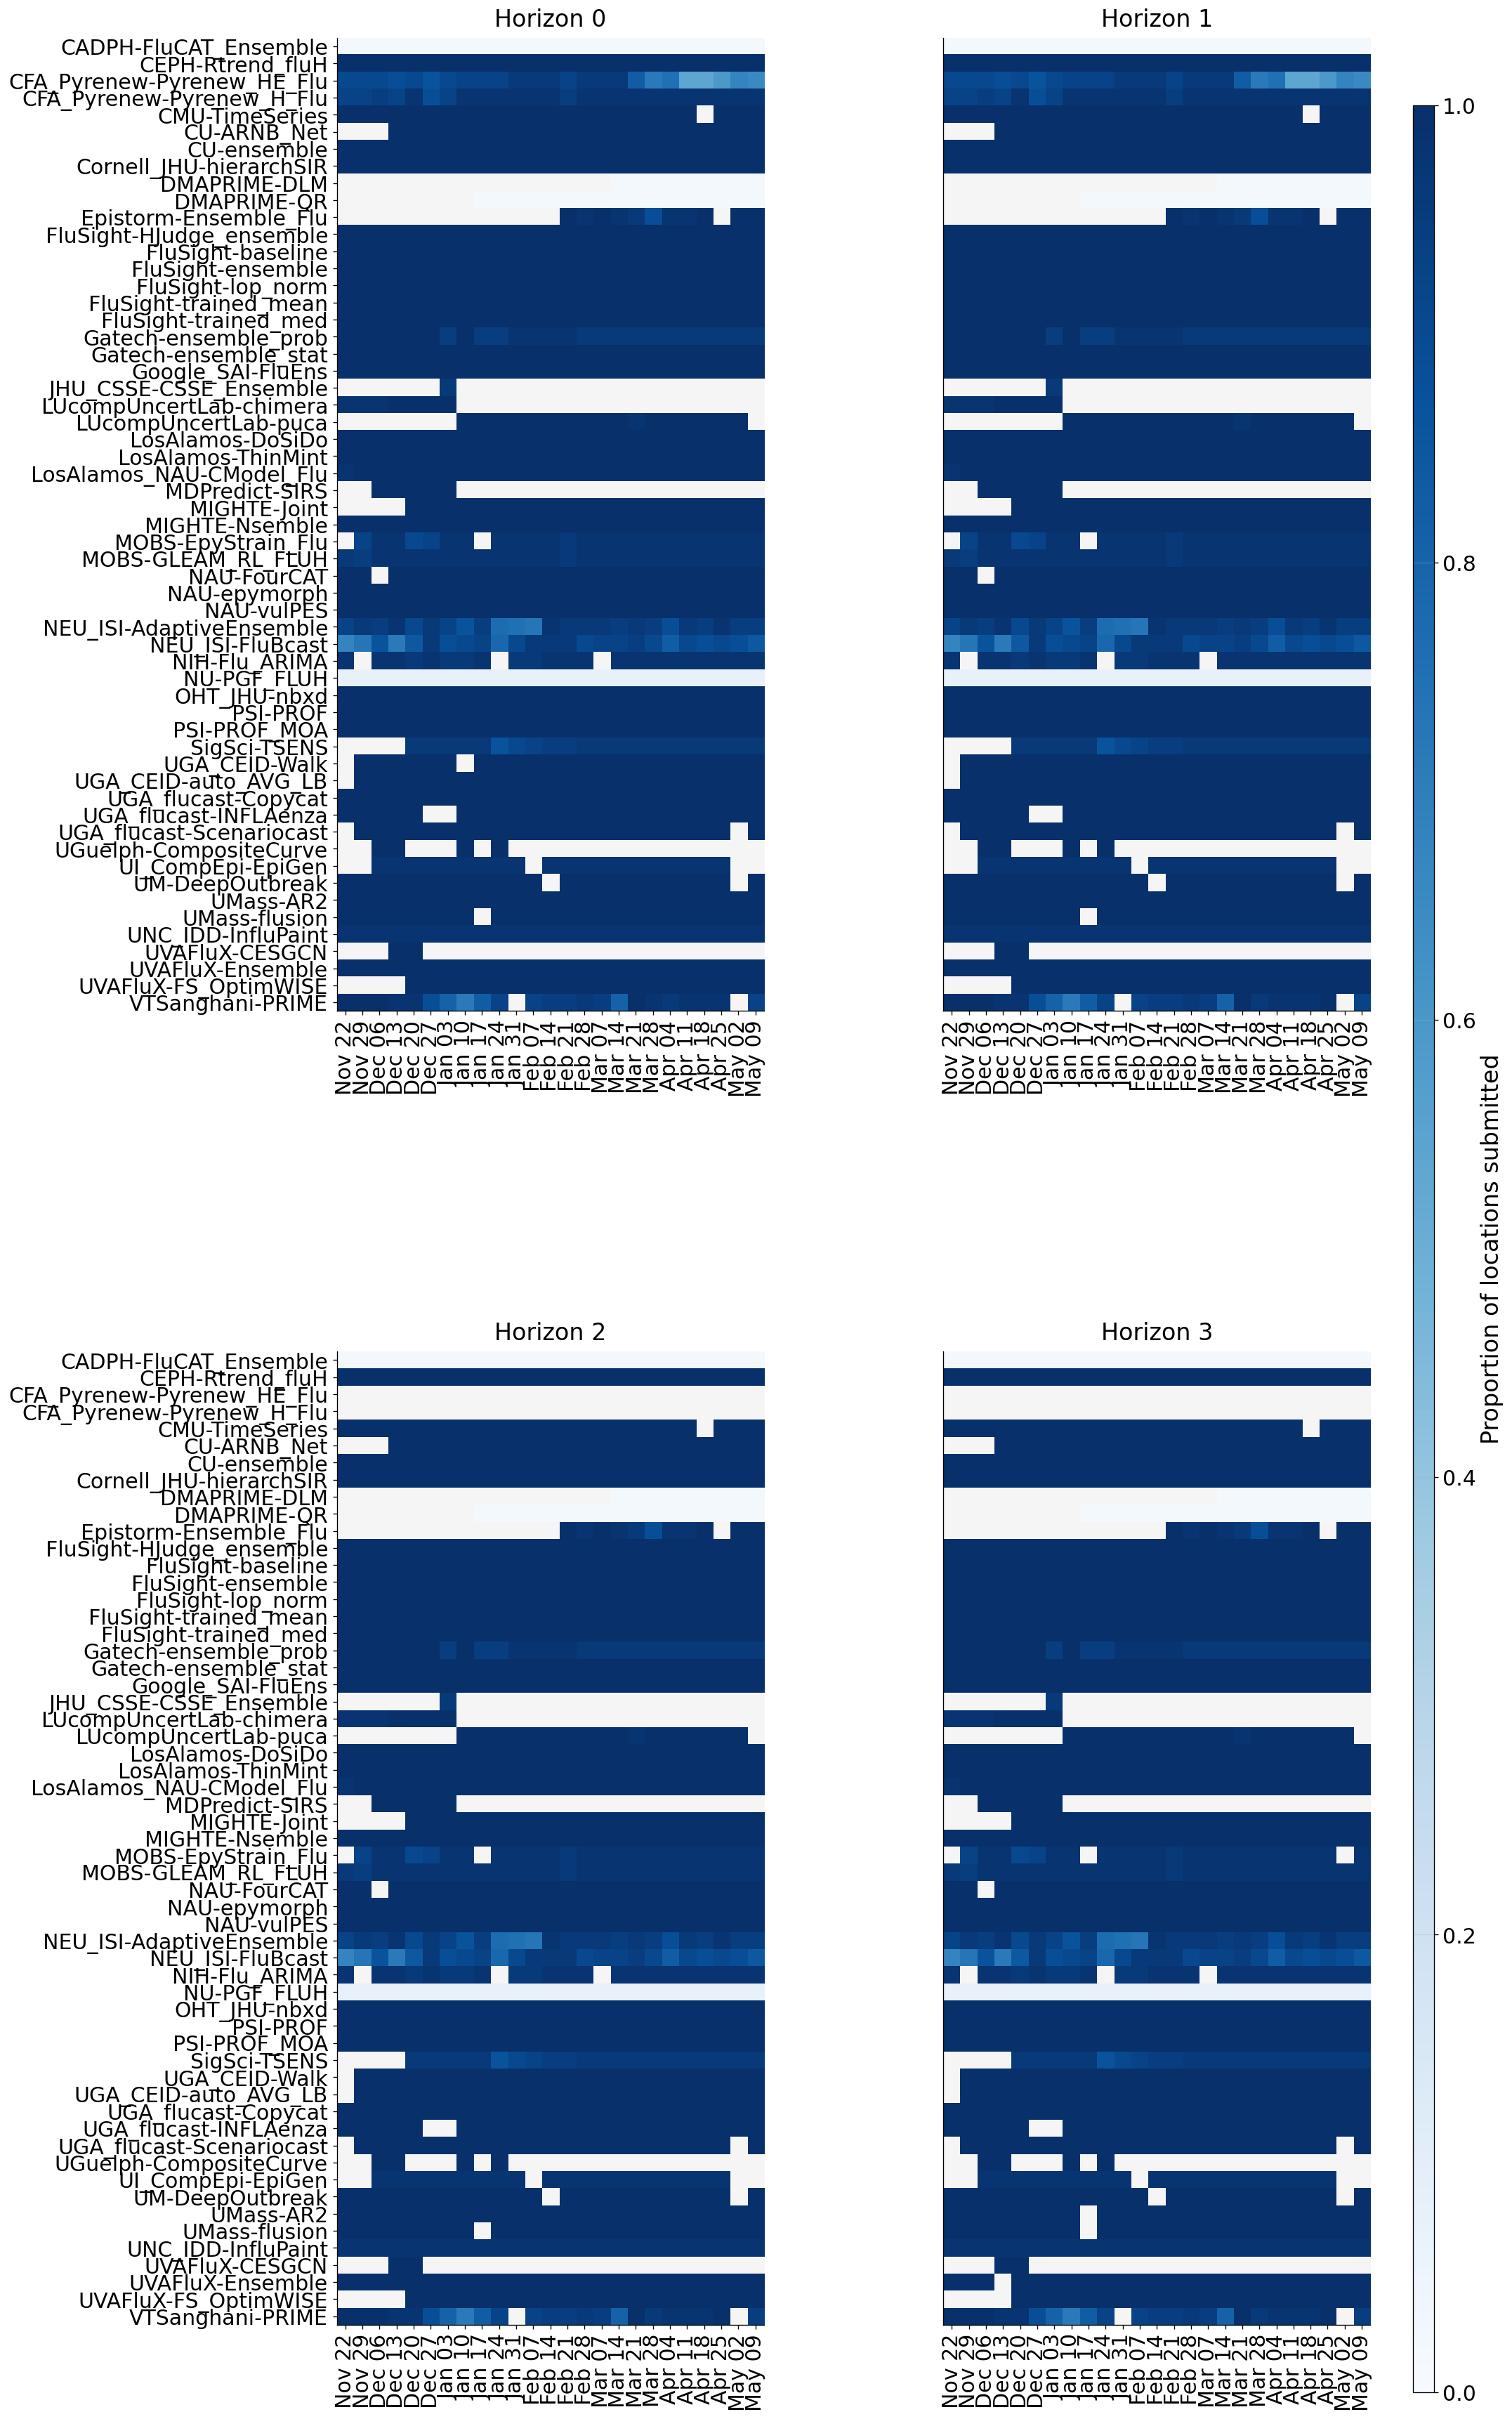

In [32]:
# Heatmap: proportion of locations submitted per (model, week, horizon)
# Built from FORECASTS (not scores) so the heatmap shows what was actually
# submitted, independent of whether truth data is available yet.

forecasts_hm = pd.read_parquet(HUB.forecasts_path)
forecasts_hm = forecasts_hm[
    (forecasts_hm["target"]  == HUB.target_name) &
    (forecasts_hm["horizon"] != -1) &
    (~forecasts_hm["location"].isin(EXCLUDE_LOCS))  # match location scope set above
]

ALL_DATES_HM = sorted(forecasts_hm["reference_date"].dropna().unique())

loc_cov = (
    forecasts_hm.groupby(["model_id", "reference_date", "horizon"])["location"]
    .nunique()
    .div(N_LOCS)
    .reset_index(name="prop_locs")
)

model_order = cov.sort_values("n_tasks", ascending=False)["model_id"].tolist()

P.plot_coverage_heatmap(loc_cov, model_order, ALL_DATES_HM, ALL_HORIZONS, N_LOCS, HUB.label)

## Season Average Comparison

Model,Tasks,Pairwise Rel. log WIS,Mean log WIS,Median log WIS,Pairwise Rel. WIS,Mean WIS,Median WIS,50% coverage,95% coverage
Google_SAI-FluEns,4680,0.89,0.3002,0.2119,0.91,71.37,20.71,48.7%,93.1%
OHT_JHU-nbxd,4680,0.91,0.3028,0.1995,1.01,79.25,19.94,41.3%,83.0%
CMU-TimeSeries,4524,0.92,0.3090,0.2115,0.87,70.08,21.39,48.8%,94.0%
FluSight-trained_mean,4680,0.93,0.3124,0.2221,0.95,74.39,21.25,45.1%,89.5%
UGA_flucast-INFLAenza,4264,0.94,0.3191,0.1927,0.91,63.30,19.03,47.4%,88.0%
FluSight-HJudge_ensemble,4680,0.94,0.3164,0.2204,0.94,73.48,20.41,45.3%,88.9%
UMass-flusion,4472,0.95,0.3200,0.2198,0.92,71.03,17.80,32.5%,79.5%
NAU-vulPES,4680,0.98,0.3271,0.2254,0.93,72.31,22.36,42.3%,92.2%
FluSight-trained_med,4680,0.98,0.3292,0.2342,0.95,74.49,21.96,46.8%,90.1%
FluSight-ensemble,4680,1.00,0.3361,0.2351,1.00,78.20,21.22,46.9%,88.2%


Exported → tables/flu_summary.tex


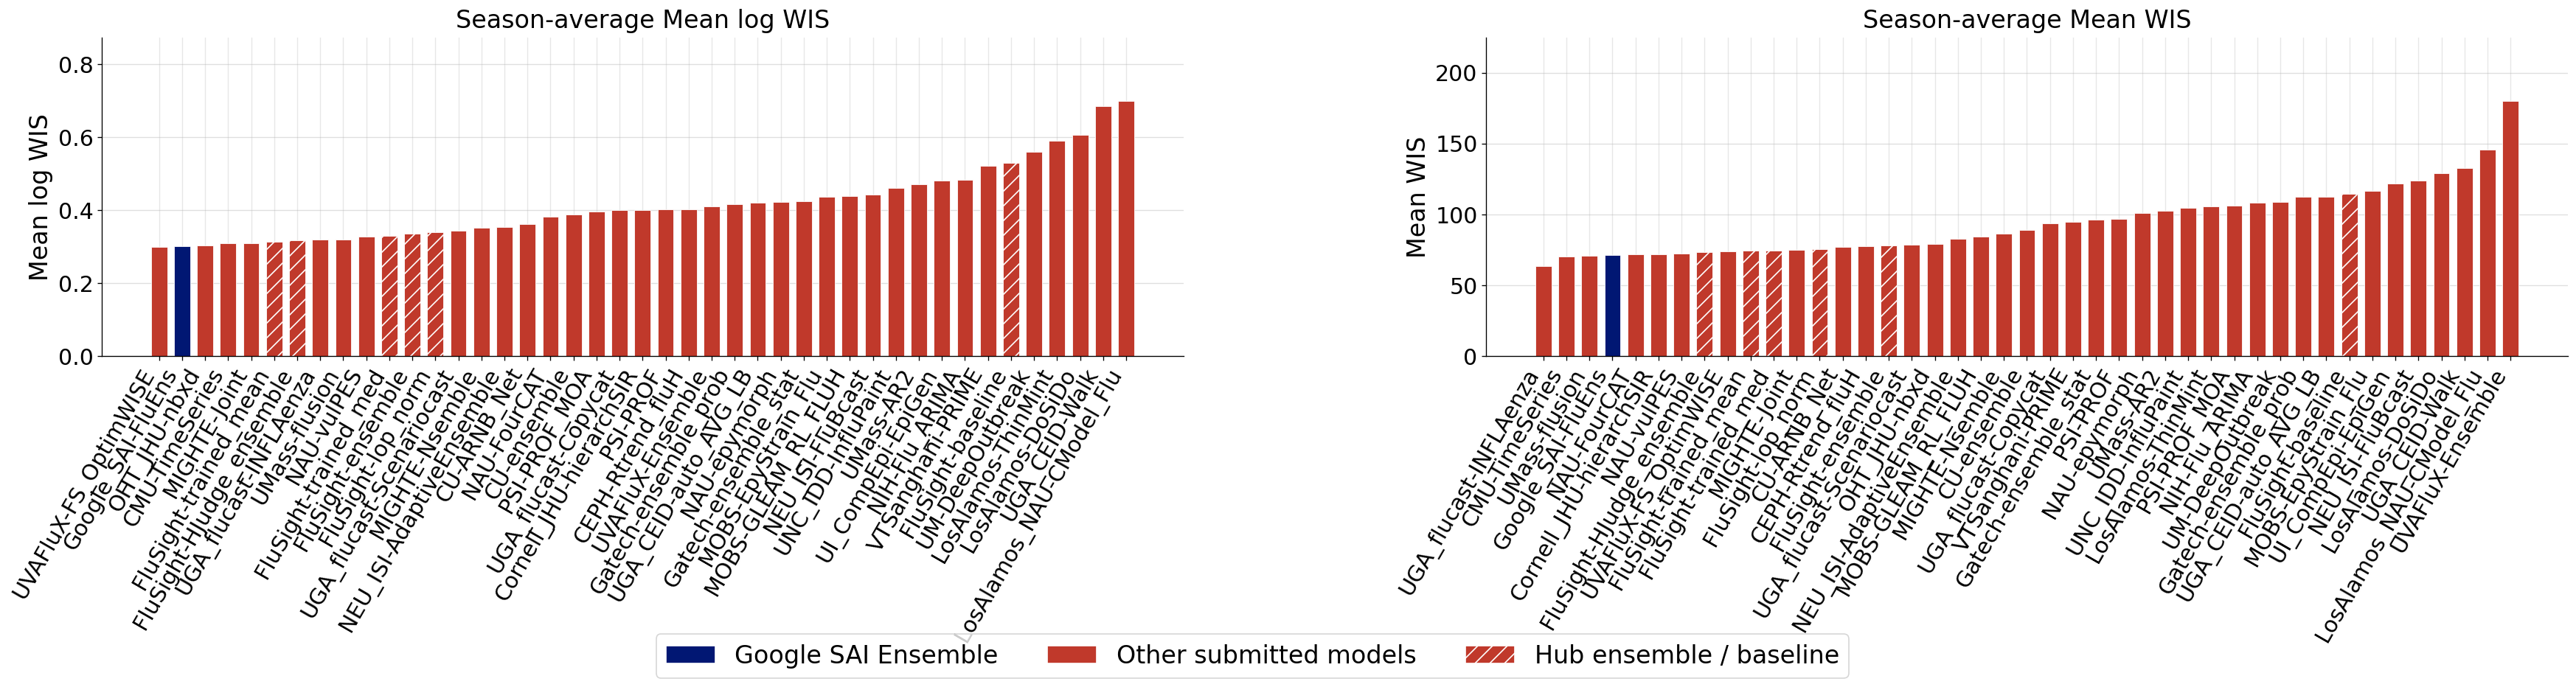

In [40]:
elig = scores[scores["model_id"].isin(set(eligible_models) | HUB_MODELS)]

summary = (
    elig.groupby("model_id", as_index=False)
    .agg(
        n_tasks        = ("wis",     "size"),
        mean_wis       = ("wis",     "mean"),
        median_wis     = ("wis",     "median"),
        mean_log_wis   = ("log_wis", "mean"),
        median_log_wis = ("log_wis", "median"),
        cov_50         = ("cov_50",  "mean"),
        cov_95         = ("cov_95",  "mean"),
    )
)

_rel     = pairwise_relative_wis(elig, baseline_model=ENSEMBLE)
_rel_log = pairwise_relative_wis(elig, baseline_model=ENSEMBLE, score_col="log_wis").rename(columns={"rel_wis": "rel_log_wis"})
summary  = (
    summary
    .merge(_rel, on="model_id", how="left")
    .merge(_rel_log, on="model_id", how="left")
    .sort_values("rel_log_wis")
)

# Diverging colormap for relative WIS: green (< 1) → white (= 1, ensemble) → orange → red (> 1)
_cmap_rel = LinearSegmentedColormap.from_list(
    "rel_wis",
    [(0.00, "#1a633a"), (0.25, "#13cb63"), (0.50, "white"), (0.75, "#fcd059"), (1.00, "#d73027")]
)

_summary_display = summary.rename(columns={
    "model_id":        "Model",
    "n_tasks":         "Tasks",
    "mean_wis":        "Mean WIS",
    "median_wis":      "Median WIS",
    "mean_log_wis":    "Mean log WIS",
    "median_log_wis":  "Median log WIS",
    "rel_wis":         "Pairwise Rel. WIS",
    "rel_log_wis":     "Pairwise Rel. log WIS",
    "cov_50":          "50% coverage",
    "cov_95":          "95% coverage",
})[[
    "Model", "Tasks",
    "Pairwise Rel. log WIS", "Mean log WIS", "Median log WIS",
    "Pairwise Rel. WIS", "Mean WIS", "Median WIS",
    "50% coverage", "95% coverage",
]]

_summary_display.to_csv("data/season_summaries/flu_summary.csv", index=False)

# fix colour scales for relative WIS : log scales w limits:
_rel_wis_log     = np.log(_summary_display["Pairwise Rel. WIS"])
_rel_log_wis_log = np.log(_summary_display["Pairwise Rel. log WIS"])
_rel_lim     = np.nanquantile(np.abs(_rel_wis_log),     0.90)
_rel_log_lim = np.nanquantile(np.abs(_rel_log_wis_log), 0.90)

show_table(
    _summary_display.style
    .format({
        "Mean WIS":              "{:.2f}",
        "Median WIS":            "{:.2f}",
        "Mean log WIS":          "{:.4f}",
        "Median log WIS":        "{:.4f}",
        "Pairwise Rel. WIS":     "{:.2f}",
        "Pairwise Rel. log WIS": "{:.2f}",
        "50% coverage":          "{:.1%}",
        "95% coverage":          "{:.1%}",
    })
    .background_gradient(subset=["Mean WIS"],     cmap="RdYlGn_r", axis=0)
    .background_gradient(subset=["Mean log WIS"], cmap="RdYlGn_r", axis=0)
    .background_gradient(
        subset=["Pairwise Rel. WIS"],
        cmap=_cmap_rel,
        gmap=_rel_wis_log.to_frame(),
        vmin=-_rel_lim,
        vmax=_rel_lim,
        axis=None,
    )
    .background_gradient(
        subset=["Pairwise Rel. log WIS"],
        cmap=_cmap_rel,
        gmap=_rel_log_wis_log.to_frame(),
        vmin=-_rel_log_lim,
        vmax=_rel_log_lim,
        axis=None,
    )
    .apply(
        lambda s: [f"color: {GOOGLE_PINK}; font-weight: bold"
                   if v == GOOGLE else "" for v in s],
        subset=["Model"], axis=0,
    )
    .hide(axis="index"),
    "summary", prefix=TABLE_PREFIX, export=EXPORT_TABLES,
)

P.plot_season_bars(
    summary,
    MODEL_COLOUR, MODEL_HATCH,
    include_n_tasks=False,
    save_path=os.path.join(PLTS_TO, f"{FOR_DISEASE}_main_summary_bars.png"),
    legend_buffer=-0.35,
)

## WIS vs logWIS

In [37]:
all_summary = (
    scores.groupby("model_id", as_index=False)
    .agg(
        mean_wis     = ("wis",     "mean"),
        mean_log_wis = ("log_wis", "mean"),
        n_tasks      = ("wis",     "size"),
    )
)
all_summary["is_eligible"] = all_summary["model_id"].isin(eligible_models)

# P.plot_wis_vs_logwis(all_summary, MODEL_COLOUR, ELIGIBILITY_THRESHOLD)

# Rank comparison (eligible models only)
rank_tbl = (
    all_summary[all_summary["is_eligible"]]
    [["model_id", "mean_wis", "mean_log_wis"]]
    .copy()
)
rank_tbl["wis_rank"]     = rank_tbl["mean_wis"].rank(method="min").astype(int)
rank_tbl["log_wis_rank"] = rank_tbl["mean_log_wis"].rank(method="min").astype(int)
rank_tbl["rank_diff"]    = rank_tbl["log_wis_rank"] - rank_tbl["wis_rank"]
rank_tbl = rank_tbl.sort_values("log_wis_rank")

show_table(
    rank_tbl[["model_id","mean_wis","wis_rank","mean_log_wis","log_wis_rank","rank_diff"]]
    .rename(columns={
        "model_id":       "Model",
        "mean_wis":       "Mean WIS",
        "wis_rank":       "WIS rank",
        "mean_log_wis":   "Mean log WIS",
        "log_wis_rank":   "log WIS rank",
        "rank_diff":      "Rank diff (log − WIS)",
    })
    .style
    .format({"Mean WIS": "{:.2f}", "Mean log WIS": "{:.4f}"})
    .background_gradient(
        subset=["Rank diff (log − WIS)"], cmap="RdBu_r",
        vmin=-rank_tbl["rank_diff"].abs().max(),
        vmax= rank_tbl["rank_diff"].abs().max(),
    )
    .apply(
        lambda s: [f"color: {GOOGLE_PINK}; font-weight: bold"
                   if v == GOOGLE else "" for v in s],
        subset=["Model"], axis=0,
    )
    .hide(axis="index"),
    "wis_rank", prefix=TABLE_PREFIX, export=EXPORT_TABLES,
)

Model,Mean WIS,WIS rank,Mean log WIS,log WIS rank,Rank diff (log − WIS)
UVAFluX-FS_OptimWISE,73.88,9,0.2996,1,-8
Google_SAI-FluEns,71.37,4,0.3002,2,-2
OHT_JHU-nbxd,79.25,18,0.3028,3,-15
CMU-TimeSeries,70.08,2,0.3090,4,2
MIGHTE-Joint,74.70,12,0.3098,5,-7
FluSight-trained_mean,74.39,10,0.3124,6,-4
FluSight-HJudge_ensemble,73.48,8,0.3164,7,-1
UGA_flucast-INFLAenza,63.30,1,0.3191,8,7
UMass-flusion,71.03,3,0.3200,9,6
NAU-vulPES,72.31,7,0.3271,10,3


Exported → tables/flu_wis_rank.tex


## Performance by Horizon

The per-horizon analysis includes the two CFA models which did not meet our eligibility criteria for the other analyes. These models only submit predictions for two horizons, and therefore do not cover $\geq 80\%$ of the task space. However, they have access to more and better data, and demonstrate good performance on the close horizons for which they submit predictions.

Models sorted by mean WIS across all horizons, ascending. 

In [38]:
# Add the two CFA models to per-horizon analysis
horizon_models = [
    "CFA_Pyrenew-Pyrenew_H_Flu",
    "CFA_Pyrenew-Pyrenew_HE_Flu"
]

Mean WIS by model and horizon:


horizon,n_tasks,0,1,2,3
UGA_flucast-INFLAenza,"4,264",28.52,53.03,79.33,98.04
CMU-TimeSeries,"4,524",33.37,61.06,87.31,102.53
UMass-flusion,"4,472",37.19,59.94,84.19,108.33
Google_SAI-FluEns,"4,680",38.54,62.71,85.09,103.99
FluSight-HJudge_ensemble,"4,680",36.75,65.38,89.79,107.24
FluSight-trained_mean,"4,680",36.88,66.04,90.60,109.43
Cornell_JHU-hierarchSIR,"4,680",39.79,64.09,86.02,102.76
FluSight-trained_med,"4,680",37.86,66.70,90.24,108.39
NAU-vulPES,"4,680",38.83,66.22,87.23,101.60
FluSight-lop_norm,"4,680",38.46,66.72,91.69,109.31


Exported → tables/flu_wis_by_horizon.tex

Mean log WIS by model and horizon:


horizon,n_tasks,0,1,2,3
CMU-TimeSeries,"4,524",0.1950,0.2784,0.3558,0.4192
Google_SAI-FluEns,"4,680",0.2057,0.2758,0.3380,0.3953
FluSight-trained_mean,"4,680",0.1979,0.2853,0.3581,0.4248
UGA_flucast-INFLAenza,"4,264",0.1981,0.2866,0.3686,0.4433
FluSight-HJudge_ensemble,"4,680",0.2022,0.2895,0.3649,0.4254
OHT_JHU-nbxd,"4,680",0.2097,0.2878,0.3444,0.3819
UMass-flusion,"4,472",0.2129,0.2869,0.3590,0.4385
MIGHTE-Joint,"3,848",0.2066,0.2966,0.3555,0.3976
FluSight-trained_med,"4,680",0.2077,0.3020,0.3790,0.4455
UVAFluX-FS_OptimWISE,"3,848",0.2218,0.2900,0.3384,0.3609


Exported → tables/flu_logwis_by_horizon.tex


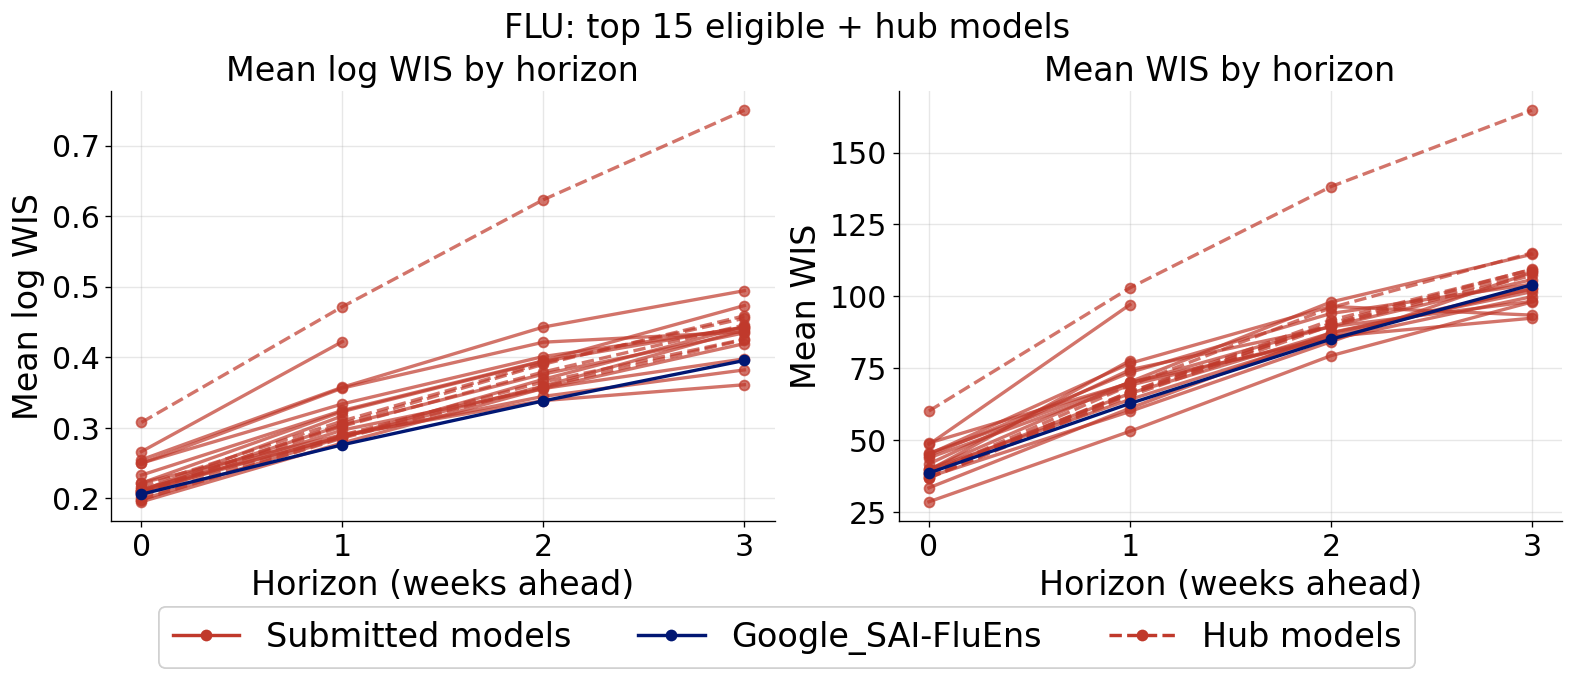

In [52]:
# Mean WIS & log WIS by model × horizon (eligible + hub models + horizon-only models)
elig_hor = scores[scores["model_id"].isin(set(eligible_models) | HUB_MODELS | set(horizon_models))]

by_hor_wis = (
    elig_hor.groupby(["model_id", "horizon"])["wis"]
    .mean()
    .unstack("horizon")
    .round(2)
)
by_hor_log = (
    elig_hor.groupby(["model_id", "horizon"])["log_wis"]
    .mean()
    .unstack("horizon")
    .round(4)
)

n_tasks_hor = elig_hor.groupby("model_id").size().rename("n_tasks")

by_hor_wis = by_hor_wis.loc[by_hor_wis[[0, 1]].sum(axis=1).sort_values().index]
by_hor_log = by_hor_log.loc[by_hor_log[[0, 1]].sum(axis=1).sort_values().index]

print("Mean WIS by model and horizon:")
tmp = by_hor_wis.copy()
tmp.columns = tmp.columns.astype(int)
tmp.index.name = None
tmp.insert(0, "n_tasks", n_tasks_hor)
_hor_cols = [c for c in tmp.columns if c != "n_tasks"]
show_table(
    tmp.style
    .apply(C.median_gradient, subset=_hor_cols, axis=0)
    .format("{:.2f}", subset=_hor_cols, na_rep="")
    .format("{:,}", subset=["n_tasks"])
    .apply_index(
        lambda s: [f"color: {GOOGLE_PINK}; font-weight: bold" if v == GOOGLE else "" for v in s],
        axis=0
    ),
    "wis_by_horizon", prefix=TABLE_PREFIX, export=EXPORT_TABLES,
)

print("\nMean log WIS by model and horizon:")
tmp = by_hor_log.copy()
tmp.columns = tmp.columns.astype(int)
tmp.index.name = None
tmp.insert(0, "n_tasks", n_tasks_hor)
show_table(
    tmp.style
    .apply(C.median_gradient, subset=_hor_cols, axis=0)
    .format("{:.4f}", subset=_hor_cols, na_rep="")
    .format("{:,}", subset=["n_tasks"])
    .apply_index(
        lambda s: [f"color: {GOOGLE_PINK}; font-weight: bold" if v == GOOGLE else "" for v in s],
        axis=0
    ),
    "logwis_by_horizon", prefix=TABLE_PREFIX, export=EXPORT_TABLES,
)

P.plot_by_horizon(by_hor_wis, by_hor_log, ALL_HORIZONS, MODEL_COLOUR,
                  hub_models=HUB_MODELS, hub_label=HUB.label, main_model=GOOGLE,
                  save_path=os.path.join(PLTS_TO, f"{FOR_DISEASE}_by_horizon.png"))

## Performance by State

In [43]:
# Mean WIS & log WIS per jurisdiction (eligible + hub models)
_loc_scores = scores[scores["model_id"].isin(set(eligible_models) | HUB_MODELS)]

by_loc_wis = (
    _loc_scores.groupby(["model_id", "location"])["wis"]
    .mean().unstack("location").round(2)
)
by_loc_log = (
    _loc_scores.groupby(["model_id", "location"])["log_wis"]
    .mean().unstack("location").round(4)
)

# Rename location codes → display names
_raw = pd.read_parquet(HUB.truth_path)
_loc_names = (
    _raw[["location", "location_name"]].dropna()
    .drop_duplicates("location").set_index("location")["location_name"].to_dict()
)
del _raw

by_loc_wis.columns = [_loc_names.get(c, c) for c in by_loc_wis.columns]
by_loc_log.columns = [_loc_names.get(c, c) for c in by_loc_log.columns]

# Sort models by overall mean log WIS (best first)
by_loc_log = by_loc_log.loc[by_loc_log.mean(axis=1).sort_values().index]
by_loc_wis = by_loc_wis.reindex(by_loc_log.index)

# Table: Google + main ensemble + top-3 eligible models (by season-average log WIS)
_top3 = [
    m for m in by_loc_log.mean(axis=1).sort_values().index
    if m in eligible_models and m not in {GOOGLE, ENSEMBLE}
][:3]
_key = [m for m in ([GOOGLE, ENSEMBLE] + _top3) if m in by_loc_log.index]
_tbl = by_loc_log.loc[_key].T
if GOOGLE in _tbl.columns:
    _tbl = _tbl.sort_values(GOOGLE, ascending=True)

print("Mean log WIS per jurisdiction (sorted best → worst for Google):")
show_table(
    _tbl.style
    .background_gradient(cmap="RdYlGn_r", axis=0)
    .format("{:.4f}")
    .apply_index(
        lambda idx: [
            f"color: {GOOGLE_PINK}; font-weight: bold" if v == GOOGLE else ""
            for v in idx
        ],
        axis=1,
    ),
    "logwis_by_location", prefix=TABLE_PREFIX, export=EXPORT_TABLES,
)

Mean log WIS per jurisdiction (sorted best → worst for Google):


model_id,Google_SAI-FluEns,FluSight-ensemble,UVAFluX-FS_OptimWISE,OHT_JHU-nbxd,CMU-TimeSeries
California,0.1487,0.1887,0.2038,0.1985,0.1900
Washington,0.1766,0.1911,0.2212,0.1885,0.1920
Texas,0.1827,0.1929,0.1820,0.2284,0.2249
Puerto Rico,0.1851,0.1829,0.1799,0.4089,0.2056
Florida,0.2089,0.2256,0.2667,0.2498,0.2367
Tennessee,0.2200,0.2672,0.2107,0.2247,0.2847
Louisiana,0.2353,0.2729,0.2908,0.3120,0.2824
Arizona,0.2467,0.2556,0.2522,0.2776,0.2456
Pennsylvania,0.2478,0.2420,0.2353,0.2281,0.2199
Idaho,0.2506,0.2593,0.2644,0.2226,0.2724


Exported → tables/flu_logwis_by_location.tex


/Users/smart/Documents/Projects/Google/ERA_epi/performance-analysis/src/plotting.py:79: UserWarning: constrained_layout not applied because axes sizes collapsed to zero.  Try making figure larger or Axes decorations smaller.
  title = "Submission coverage: proportion of locations per (model, reference week)"
/Users/smart/Documents/Projects/Google/ERA_epi/performance-analysis/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: constrained_layout not applied because axes sizes collapsed to zero.  Try making figure larger or Axes decorations smaller.
  fig.canvas.print_figure(bytes_io, **kw)


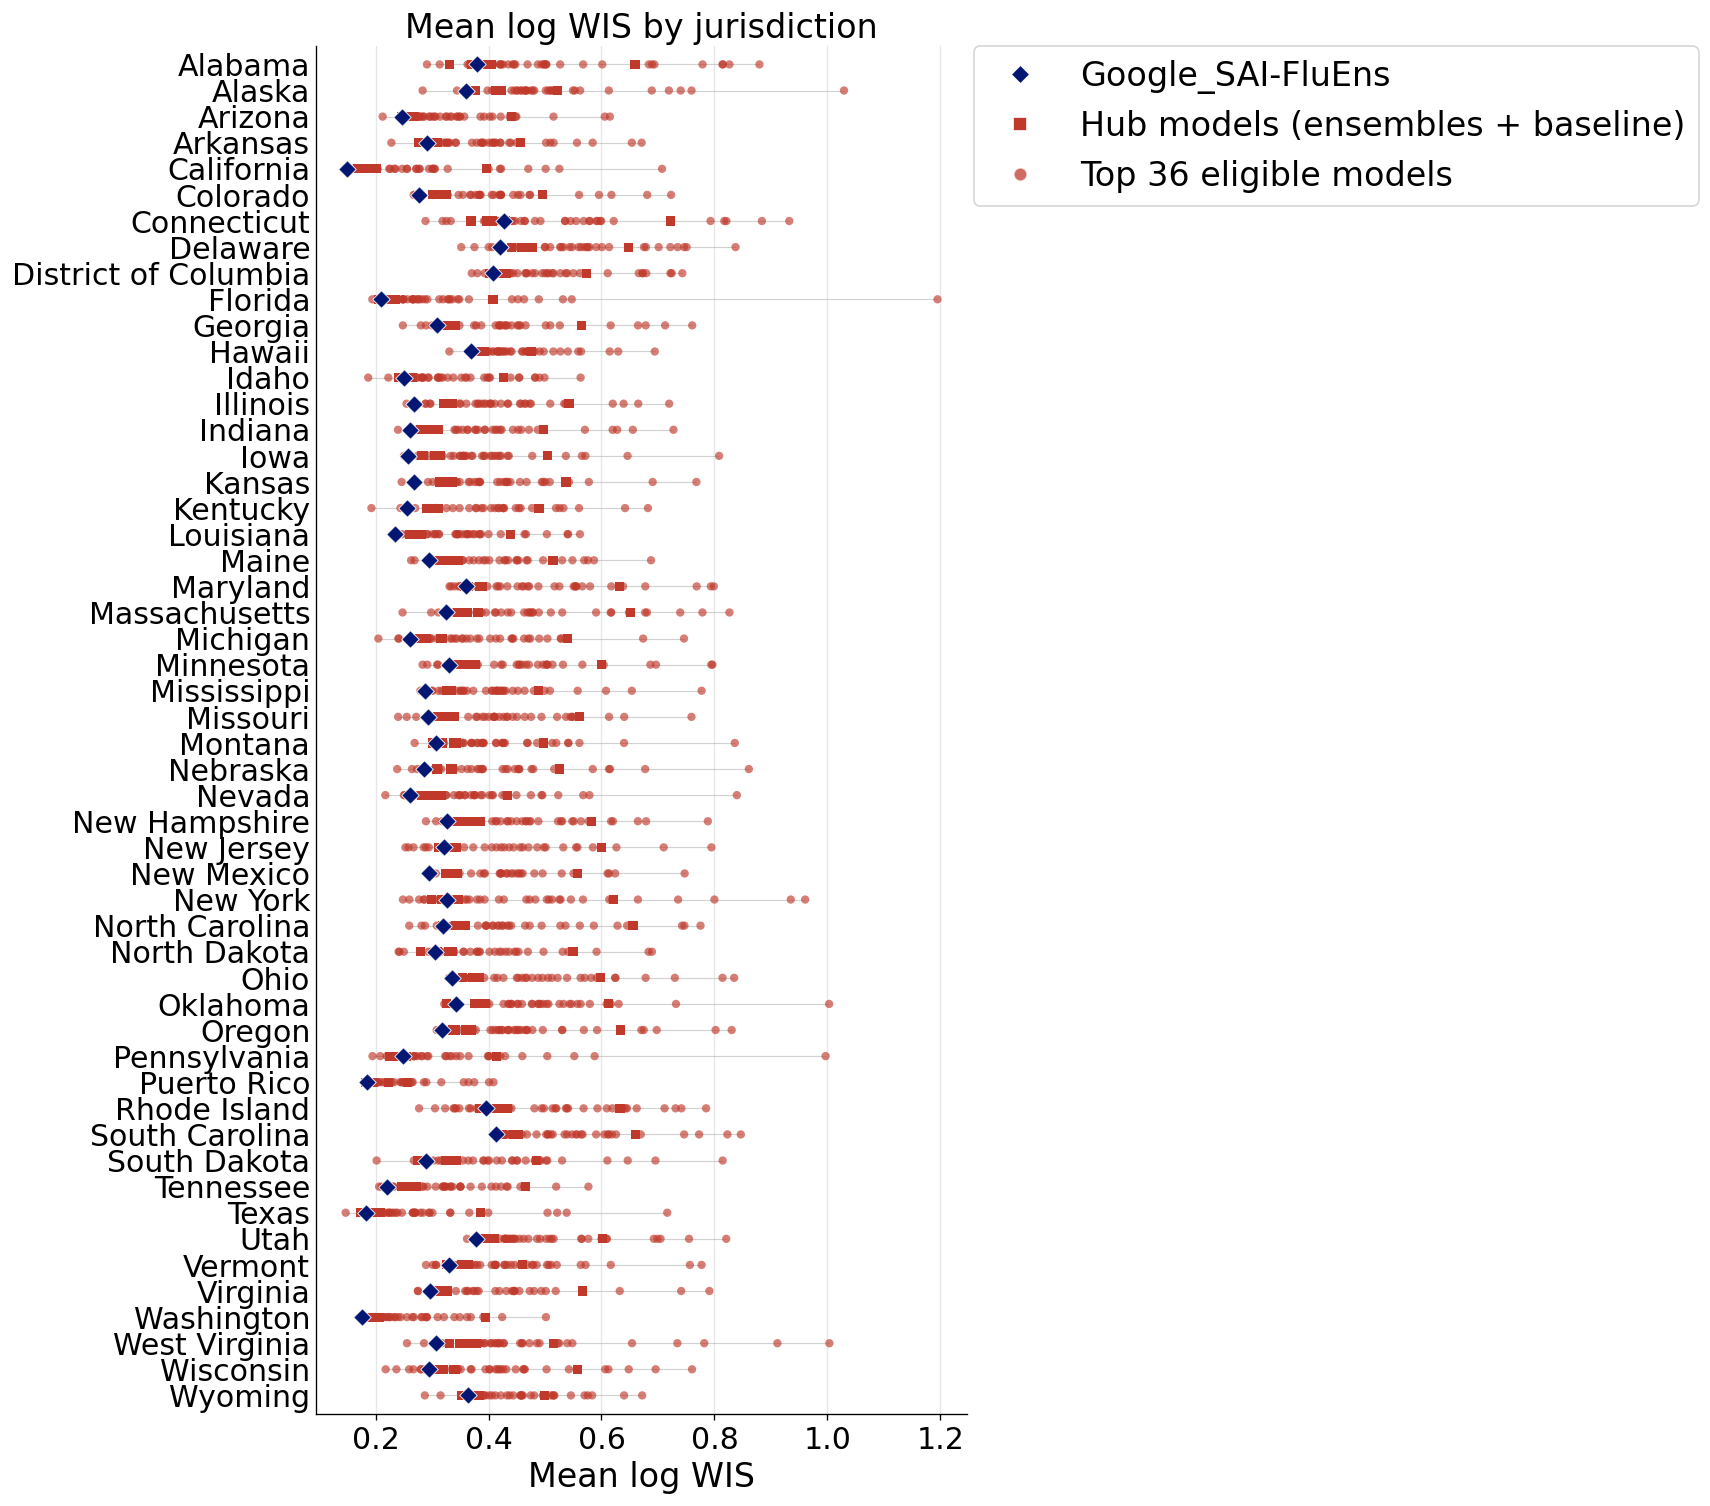

In [50]:
P.plot_by_location(
    by_loc_log, MODEL_COLOUR,
    hub_models=HUB_MODELS,
    hub_label=HUB.label,
    main_model=GOOGLE,
    save_path=os.path.join(PLTS_TO, f"{FOR_DISEASE}_by_location.png"),
    hub_legend_label="Hub models (ensembles + baseline)"
)

## Performance over Reference Time 

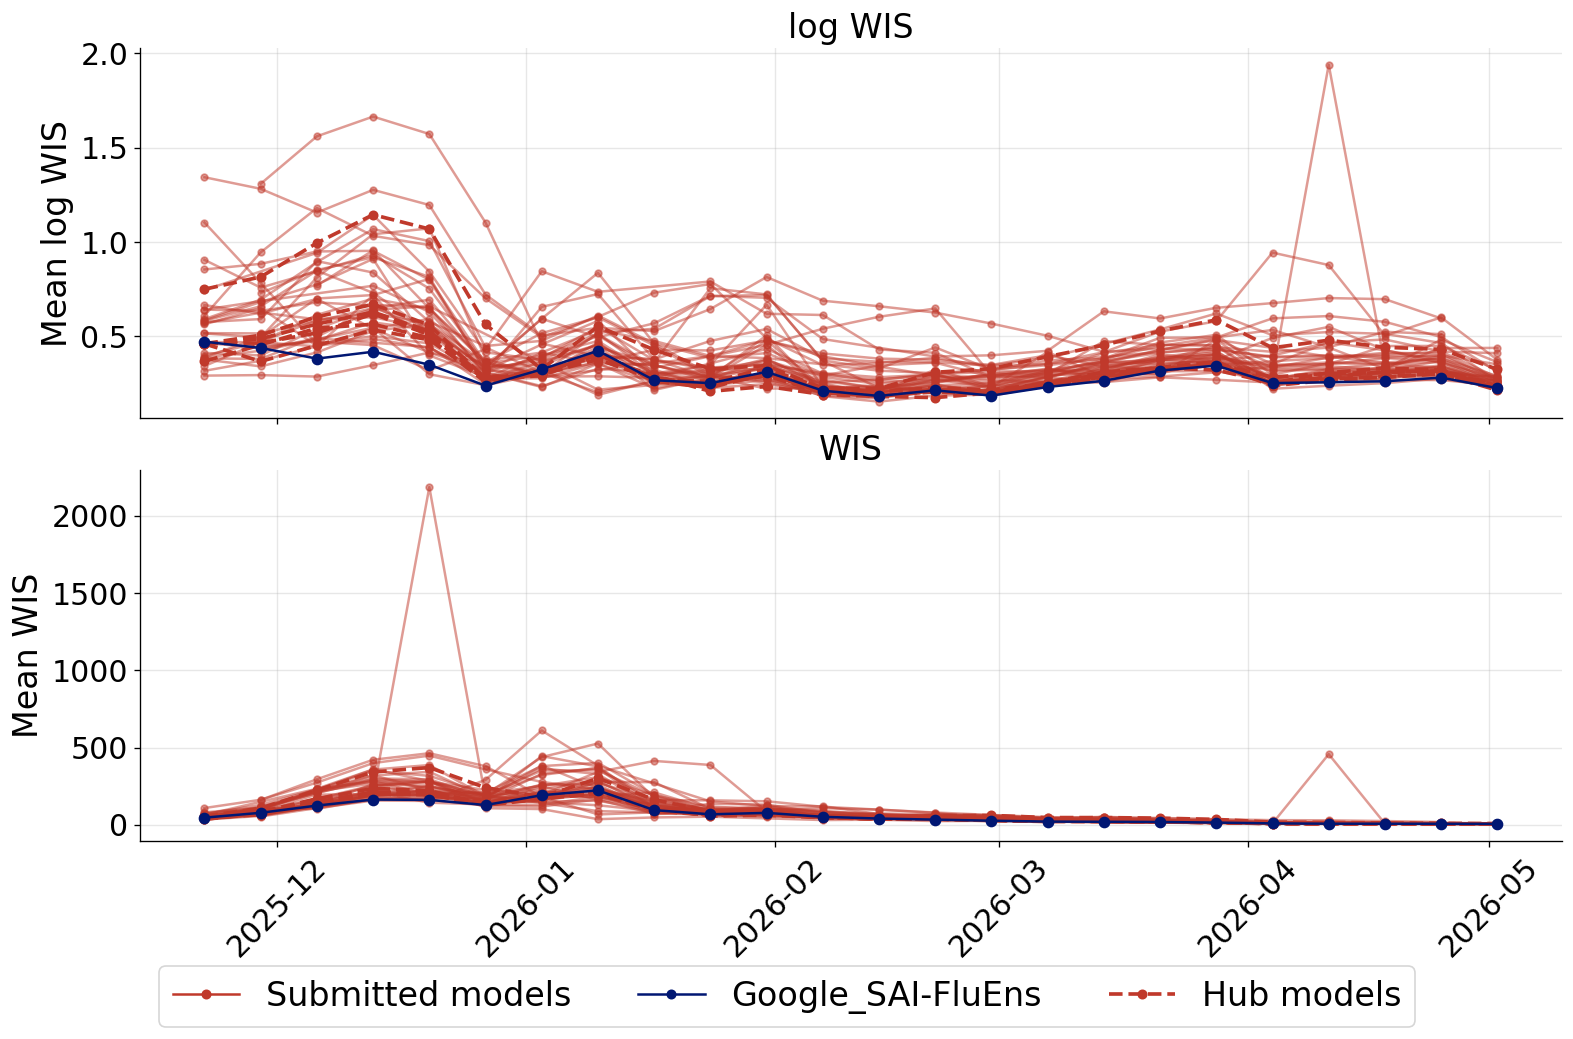

Reference date,Best WIS model,Best WIS,Best log WIS model,Best log WIS
2025-11-22,CEPH-Rtrend_fluH,32.57,OHT_JHU-nbxd,0.2927
2025-11-29,MOBS-EpyStrain_Flu,53.68,OHT_JHU-nbxd,0.2954
2025-12-06,NAU-epymorph,103.04,OHT_JHU-nbxd,0.2875
2025-12-13,MOBS-EpyStrain_Flu,157.07,OHT_JHU-nbxd,0.3483
2025-12-20,UMass-flusion,143.08,UMass-flusion,0.3002
2025-12-27,VTSanghani-PRIME,107.49,Google_SAI-FluEns,0.2393
2026-01-03,VTSanghani-PRIME,101.78,NAU-FourCAT,0.2321
2026-01-10,VTSanghani-PRIME,36.35,CMU-TimeSeries,0.1909
2026-01-17,VTSanghani-PRIME,47.54,MOBS-GLEAM_RL_FLUH,0.2170
2026-01-24,VTSanghani-PRIME,52.55,FluSight-trained_mean,0.2094


Exported → tables/flu_best_by_week.tex


In [46]:
plot_models = sorted(set(eligible_models) | HUB_MODELS)

# Weekly mean WIS / log WIS averaged over horizons and locations
weekly = (
    scores[scores["model_id"].isin(plot_models)]
    .groupby(["model_id", "reference_date"])[["wis", "log_wis"]]
    .mean()
    .reset_index()
)

# plot: weekly mean performance over reference dates
P.plot_weekly_scores(weekly, plot_models, MODEL_COLOUR, HUB_MODELS, HUB.label, main_model=GOOGLE,
                     save_path=os.path.join(PLTS_TO, f"{FOR_DISEASE}_weekly_performance.png"))

# Best model by week (eligible only)
weekly_elig = weekly[weekly["model_id"].isin(eligible_models)]

best_wis_idx = weekly_elig.groupby("reference_date")["wis"].idxmin()
best_log_idx = weekly_elig.groupby("reference_date")["log_wis"].idxmin()

best_by_week = pd.DataFrame({
    "Reference date":    weekly_elig.loc[best_wis_idx, "reference_date"].dt.strftime("%Y-%m-%d").values,
    "Best WIS model":    weekly_elig.loc[best_wis_idx, "model_id"].values,
    "Best WIS":          weekly_elig.loc[best_wis_idx, "wis"].values,
    "Best log WIS model":weekly_elig.loc[best_log_idx, "model_id"].values,
    "Best log WIS":      weekly_elig.loc[best_log_idx, "log_wis"].values,
})

show_table(
    best_by_week.style
    .format({"Best WIS": "{:.2f}", "Best log WIS": "{:.4f}"})
    .hide(axis="index")
    .apply(
        lambda s: [f"color: {GOOGLE_PINK}; font-weight: bold"
                   if v == GOOGLE else "" for v in s],
        subset=["Best WIS model", "Best log WIS model"], axis=0,
    ),
    "best_by_week", prefix=TABLE_PREFIX, export=EXPORT_TABLES,
)

## Standardised Rank Distribution

* White line further right $\implies$ median rank of that model is higher $\implies$ model is more often ranked near the **top** compared to other models $\implies$ better model. 
* Distribution at higher $x$ values $\implies$ better model. 
* Models ordered with best models by Q1 ordering near the top: ordering prioritises models that never have very bad performance over models that are merely good on average.

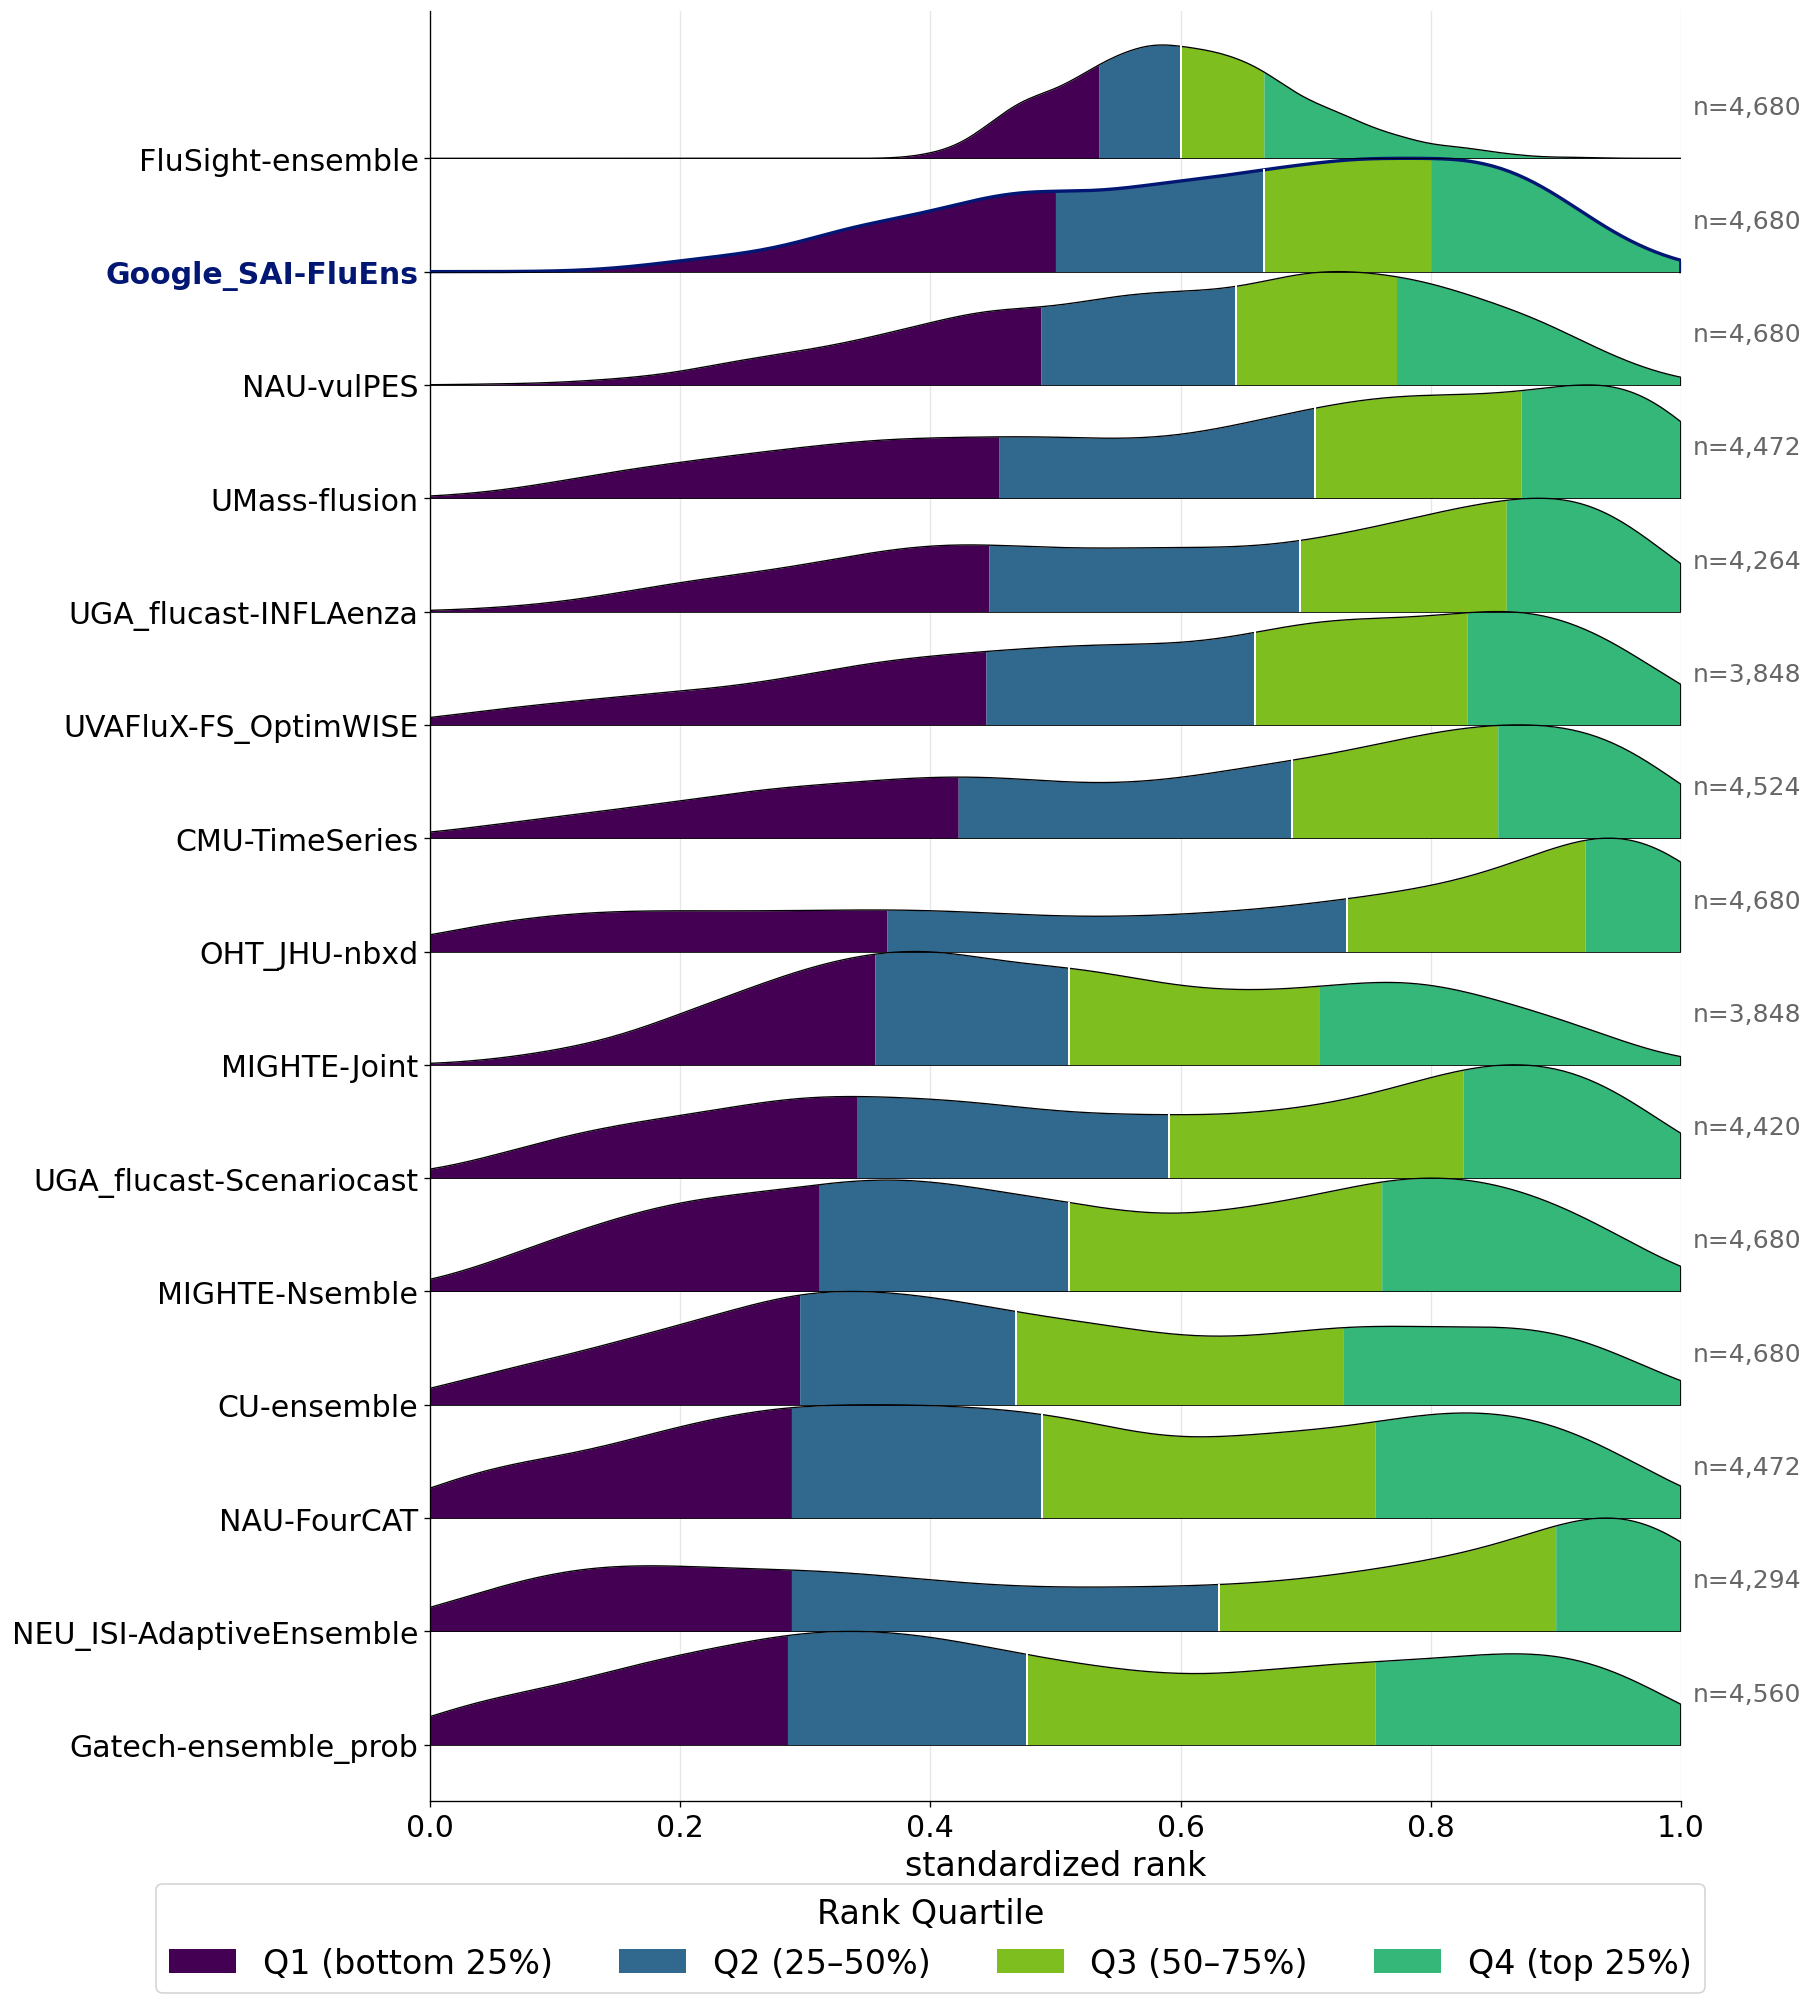

In [47]:
P.plot_rank_distribution(
    scores,
    [m for m in eligible_models if m not in set(HUB.extra_ensemble_ids)],
    MODEL_COLOUR,
    score_col="log_wis",
    top_n=15,
    main_model=GOOGLE,
    hub_label=HUB.label,
    show_n_tasks=True,
    save_path=os.path.join(PLTS_TO, f"{FOR_DISEASE}_rank_distribution.png"),
)